In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        66   (2094, 964)   float32   


In [4]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelength')

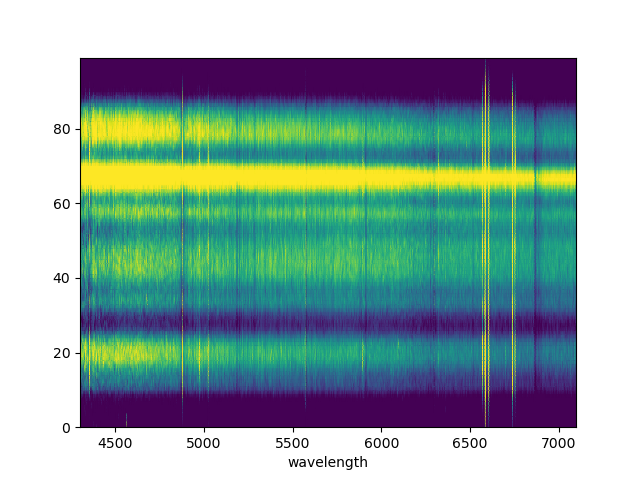

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

In [6]:
z = 0.00394
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/PSF/Real_seeing_NGC4904.txt")
sigma = seeing[0] / 2.35

In [7]:
l_HA

6588.85822

Text(0.5, 1.0, 'H$\\alpha$')

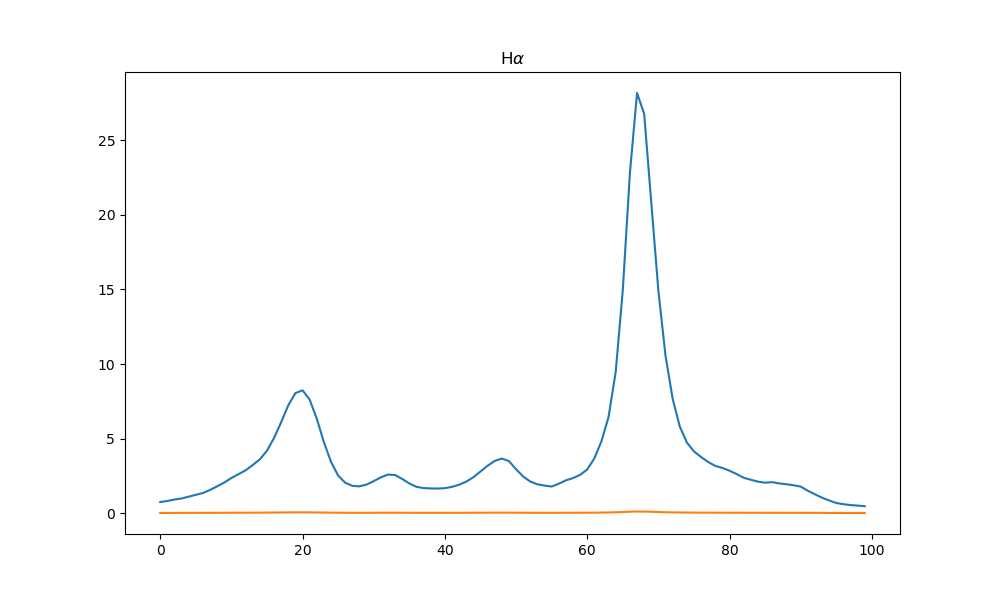

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 2661.855003112789
differential_evolution step 2: f(x)= 2450.8430928495036
differential_evolution step 3: f(x)= 2450.8430928495036
differential_evolution step 4: f(x)= 2450.8430928495036
differential_evolution step 5: f(x)= 2450.8430928495036
differential_evolution step 6: f(x)= 2390.838490894548
differential_evolution step 7: f(x)= 2383.871644274133
differential_evolution step 8: f(x)= 2340.528279238364
differential_evolution step 9: f(x)= 2340.528279238364
differential_evolution step 10: f(x)= 2340.528279238364
differential_evolution step 11: f(x)= 2340.528279238364
differential_evolution step 12: f(x)= 2340.528279238364
differential_evolution step 13: f(x)= 2340.528279238364
differential_evolution step 14: f(x)= 2339.456919392871
differential_evolution step 15: f(x)= 2339.456919392871
differential_evolution step 16: f(x)= 2339.456919392871
differential_evolution step 17: f(x)= 2331.411763998657
differential_evolution step 18: f(x)= 2329.6553619451

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\2146677439.py:7: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=2.6870, r_e=35.1700, n=0.1150, x_0=47.9728
[0.36802011 7.38989907 0.06520118 1.62140125]
3348.109730761913
3356.5307833934917 0.0 3366.5304115058652 4


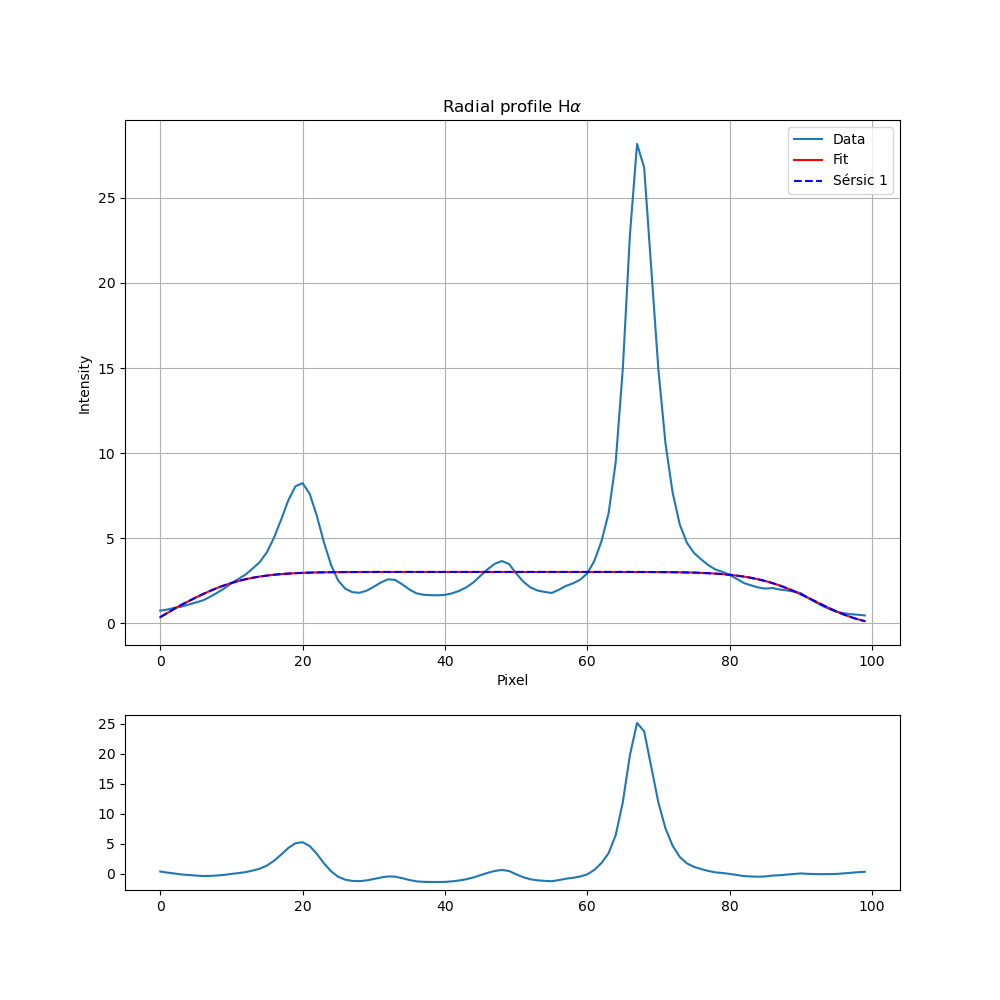

In [11]:
aic = np.zeros(7)
bic = np.zeros(7)
chi_quadr = np.zeros(7)
chi_quadro = np.zeros(7)
red_chi = np.zeros(7)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 1814.2256865550744
differential_evolution step 2: f(x)= 589.6538509283259
differential_evolution step 3: f(x)= 589.6538509283259
differential_evolution step 4: f(x)= 589.6538509283259
differential_evolution step 5: f(x)= 589.6538509283259
differential_evolution step 6: f(x)= 567.079832119609
differential_evolution step 7: f(x)= 567.079832119609
differential_evolution step 8: f(x)= 198.9593767603354
differential_evolution step 9: f(x)= 198.9593767603354
differential_evolution step 10: f(x)= 198.9593767603354
differential_evolution step 11: f(x)= 198.9593767603354
differential_evolution step 12: f(x)= 198.9593767603354
differential_evolution step 13: f(x)= 198.9593767603354
differential_evolution step 14: f(x)= 198.9593767603354
differential_evolution step 15: f(x)= 196.6984013311153
differential_evolution step 16: f(x)= 184.09296735623442
differential_evolution step 17: f(x)= 184.09296735623442
differential_evolution step 18: f(x)= 166.03486025330184

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0628, r_e=125.0807, n=3.2398, x_0=19.3798
Sérsic 2: I_e=0.0677, r_e=118.8027, n=4.5157, x_0=67.4606
[1.27798869e-01 2.19560830e+02 1.41498919e+00 2.41126146e-01
 1.99459036e-01 2.43724367e+02 2.93907316e+00 1.70634897e-04]
304.7140892070992
322.2965067895168 304.7140892070992 341.55545069500397 8


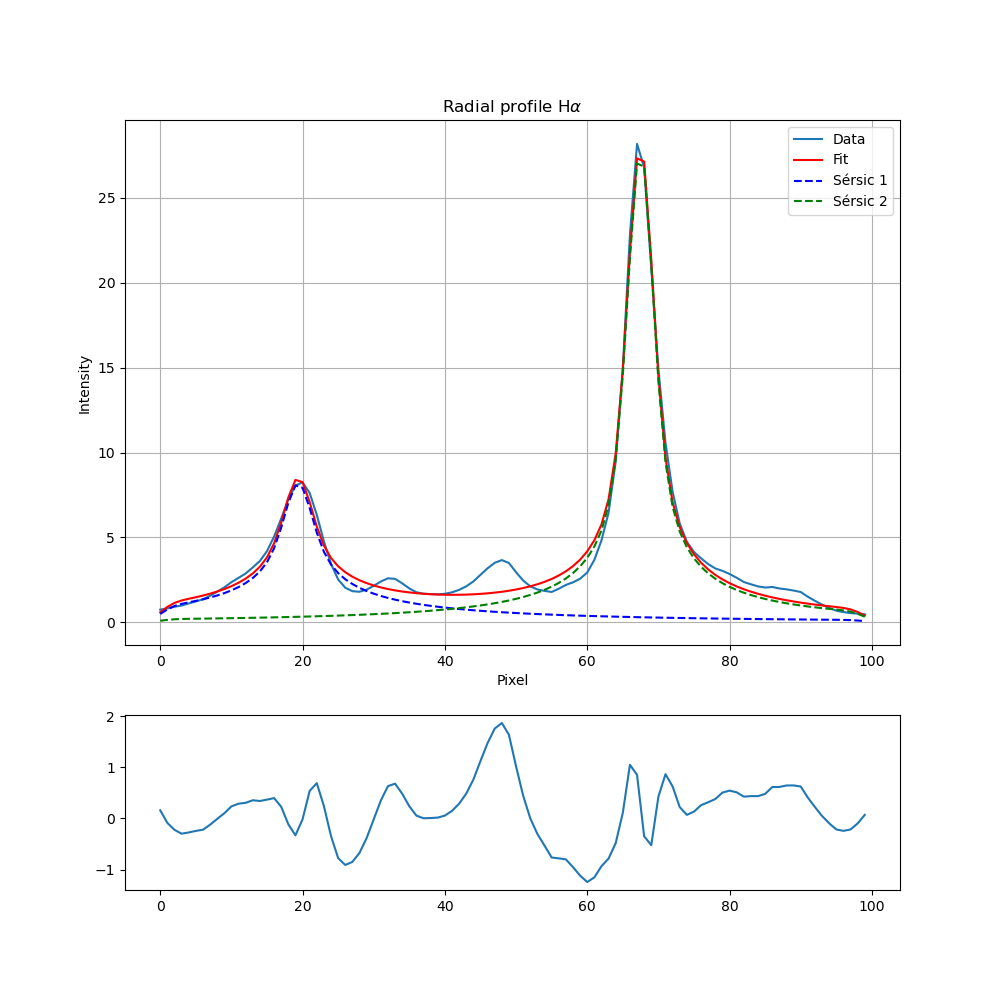

In [19]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [20]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),

     (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 50),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 5025.529364858927
differential_evolution step 2: f(x)= 5025.529364858927
differential_evolution step 3: f(x)= 2930.961642375316
differential_evolution step 4: f(x)= 2276.583456104316
differential_evolution step 5: f(x)= 2276.583456104316
differential_evolution step 6: f(x)= 2005.7016268546065
differential_evolution step 7: f(x)= 2005.7016268546065
differential_evolution step 8: f(x)= 723.6674656620249
differential_evolution step 9: f(x)= 723.6674656620249
differential_evolution step 10: f(x)= 723.6674656620249
differential_evolution step 11: f(x)= 383.1681016024368
differential_evolution step 12: f(x)= 383.1681016024368
differential_evolution step 13: f(x)= 383.1681016024368
differential_evolution step 14: f(x)= 383.1681016024368
differential_evolution step 15: f(x)= 383.1681016024368
differential_evolution step 16: f(x)= 383.1681016024368
differential_evolution step 17: f(x)= 383.1681016024368
differential_evolution step 18: f(x)= 383.1681016024368

Optimize parameters with curve fit:
Sérsic 1: I_e=3.5851, r_e=2.8810, n=0.4855, x_0=19.1620
Sérsic 2: I_e=3.9133, r_e=4.3005, n=1.6465, x_0=67.5551
Sérsic 3: I_e=1.7873, r_e=40.3003, n=0.0905, x_0=48.1127
[1.08594264 0.34874409 0.2406991  0.18739199 1.24103544 0.76542253
 0.28711248 0.07015454 0.18705225 2.94185635 0.02014789 0.50525175]
173.39610646914667
200.9823133656984 173.39610646914667 228.65814870100377 12


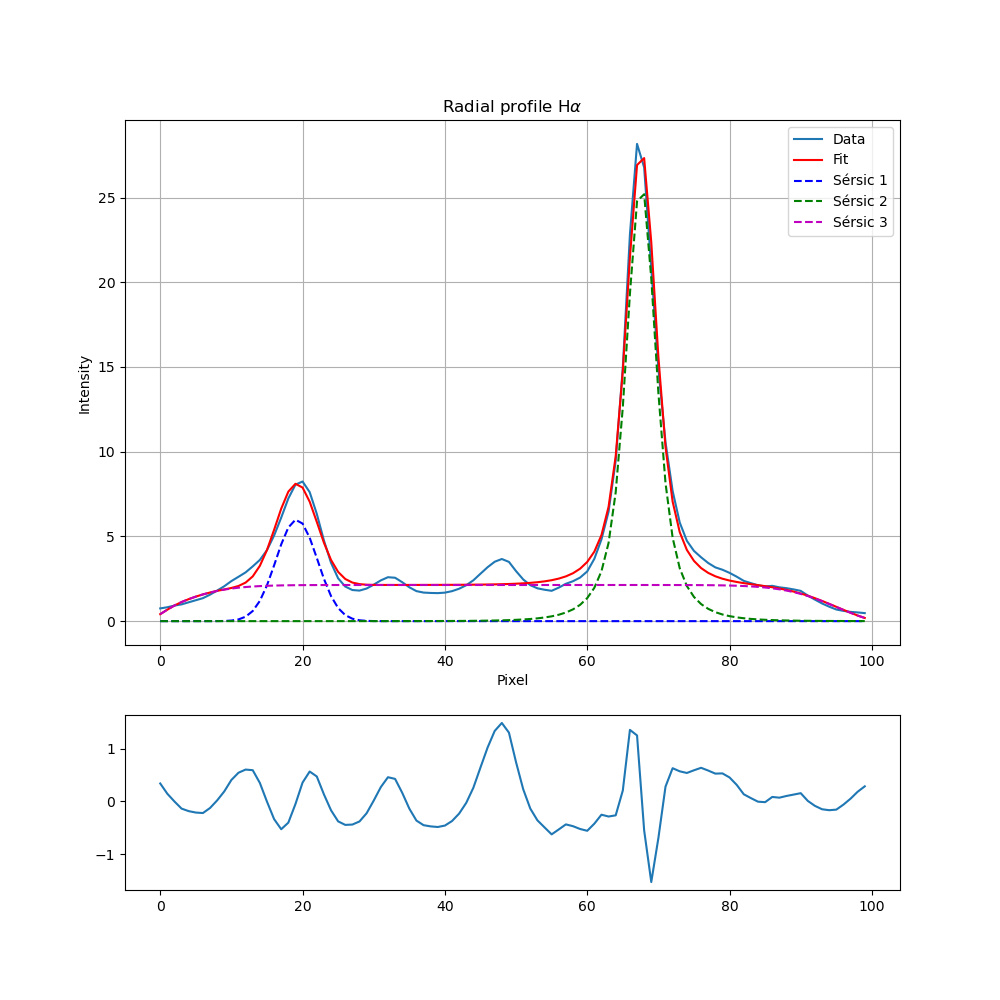

In [21]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [ ]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),

     (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (29, 33),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 36812.22904615129
differential_evolution step 2: f(x)= 36812.22904615129
differential_evolution step 3: f(x)= 32017.39970134813
differential_evolution step 4: f(x)= 32017.39970134813
differential_evolution step 5: f(x)= 19584.121580718536
differential_evolution step 6: f(x)= 12215.855484261085
differential_evolution step 7: f(x)= 12215.855484261085
differential_evolution step 8: f(x)= 6635.339598815023
differential_evolution step 9: f(x)= 6635.339598815023
differential_evolution step 10: f(x)= 2913.5458010410352
differential_evolution step 11: f(x)= 2106.3805349087997
differential_evolution step 12: f(x)= 2106.3805349087997
differential_evolution step 13: f(x)= 2106.3805349087997
differential_evolution step 14: f(x)= 2106.3805349087997
differential_evolution step 15: f(x)= 2106.3805349087997
differential_evolution step 16: f(x)= 2106.3805349087997
differential_evolution step 17: f(x)= 1703.541839107583
differential_evolution step 18: f(x)= 1703.5418

In [ ]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [24]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),

     (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (29, 33),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (78, 82)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 29: f(x)= 487.92169400406425
differential_evolution step 30: f(x)= 487.92169400406425
differential_evolution step 31: f(x)= 487.92169400406425
differential_evolution step 32: f(x)= 487.92169400406425
differential_evolution step 33: f(x)= 487.92169400406425
differential_evolution step 34: f(x)= 487.92169400406425
differential_evolution step 35: f(x)= 487.92169400406425
differential_evolution step 36: f(x)= 487.92169400406425
differential_evolution step 37: f(x)= 487.92169400406425
differential_evolution step 38: f(x)= 487.92169400406425
differential_evolution step 39: f(x)= 369.1763346530959
differential_evolution step 40: f(x)= 369.1763346530959
differential_evolution step 41: f(x)= 369.1763346530959
differential_evolution step 42: f(x)= 363.75043845654403
differential_evolution step 43: f(x)= 363.75043845654403
differential_evolution step 44: f(x)= 363.75043845654403
differential_evolution step 45: f(x)= 363.75043845654403
differential_evolution step 46: f(

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\603608188.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.8505, r_e=9.2600, n=1.5521, x_0=19.0502
Sérsic 2: I_e=2.0677, r_e=7.0729, n=2.1260, x_0=67.3737
Sérsic 3: I_e=0.7563, r_e=3.5677, n=0.9096, x_0=47.6297
Sérsic 4: I_e=0.1542, r_e=188.0462, n=1.3542, x_0=34.0396
Sérsic 5: I_e=1.1684, r_e=9.8966, n=0.1166, x_0=79.4318
[5.99274135e-01 6.33255165e+00 4.97638823e-01 1.26102639e-01
 1.46616816e+00 3.03360333e+00 4.17906937e-01 5.05897429e-02
 8.65170284e-01 3.21994175e+00 8.82711657e-01 2.58367004e-01
 3.99685308e-01 4.79993958e+02 1.29299313e+00 3.05871609e+00
 2.88435326e-01 1.23139435e+01 1.43411707e-01 1.06617895e+01]
68.1381420510975
118.77105344350257 68.1381420510975 160.24154577085935 20


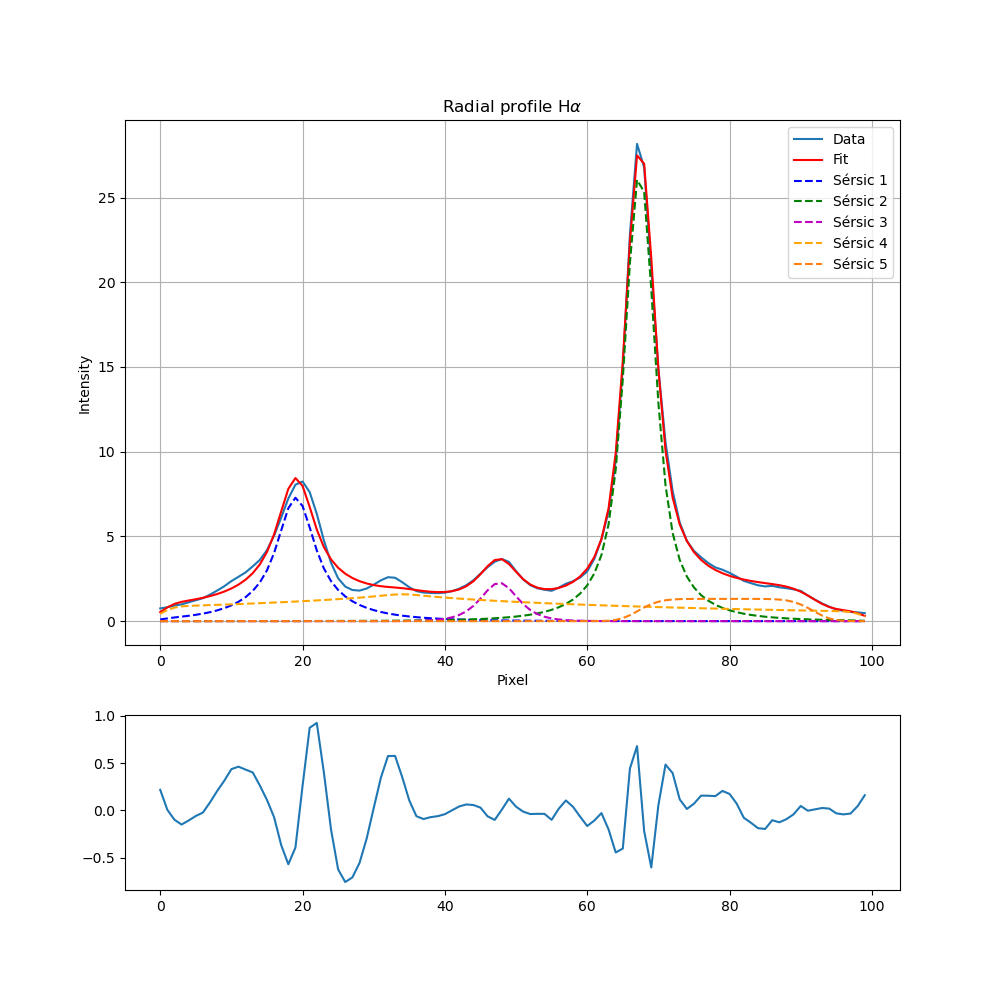

In [25]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),

     (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (29, 33),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (80, 90),
    
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 513514.4749488256
differential_evolution step 2: f(x)= 14344.55261592783
differential_evolution step 3: f(x)= 14344.55261592783
differential_evolution step 4: f(x)= 14344.55261592783
differential_evolution step 5: f(x)= 14344.55261592783
differential_evolution step 6: f(x)= 14344.55261592783
differential_evolution step 7: f(x)= 14344.55261592783
differential_evolution step 8: f(x)= 14344.55261592783
differential_evolution step 9: f(x)= 14344.55261592783
differential_evolution step 10: f(x)= 14344.55261592783
differential_evolution step 11: f(x)= 14344.55261592783
differential_evolution step 12: f(x)= 14344.55261592783
differential_evolution step 13: f(x)= 14344.55261592783
differential_evolution step 14: f(x)= 14344.55261592783
differential_evolution step 15: f(x)= 14344.55261592783
differential_evolution step 16: f(x)= 14344.55261592783
differential_evolution step 17: f(x)= 14344.55261592783
differential_evolution step 18: f(x)= 14344.55261592783
d

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\2288495773.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.5370, r_e=11.1352, n=1.9239, x_0=19.2195
Sérsic 2: I_e=0.4895, r_e=20.8501, n=3.2307, x_0=67.3368
Sérsic 3: I_e=1.2606, r_e=2.2519, n=0.4616, x_0=47.6880
Sérsic 4: I_e=1.1757, r_e=19.5975, n=0.1855, x_0=27.4149
Sérsic 5: I_e=1.0629, r_e=9.6812, n=0.3316, x_0=81.2385
Sérsic 6: I_e=0.2543, r_e=0.3957, n=5.1327, x_0=71.0536
[6.78350575e-01 1.28947240e+01 8.92686113e-01 1.20909635e-01
 3.56844532e+00 1.03184409e+02 7.32096028e+00 1.04955546e-03
 1.16141373e+00 9.83216439e-01 7.59352099e-01 3.28782644e-01
 7.77651767e-01 3.45214599e+00 1.47025488e-01 4.97099122e+00
 1.25253525e+00 1.20214186e+01 6.38788336e-01 2.26439688e+01
 8.76979006e+02 5.87051905e+02 6.30162902e+03 2.11287215e+00]
69.36929198954995
133.36929198954994 69.36929198954995 179.89337645326415 24


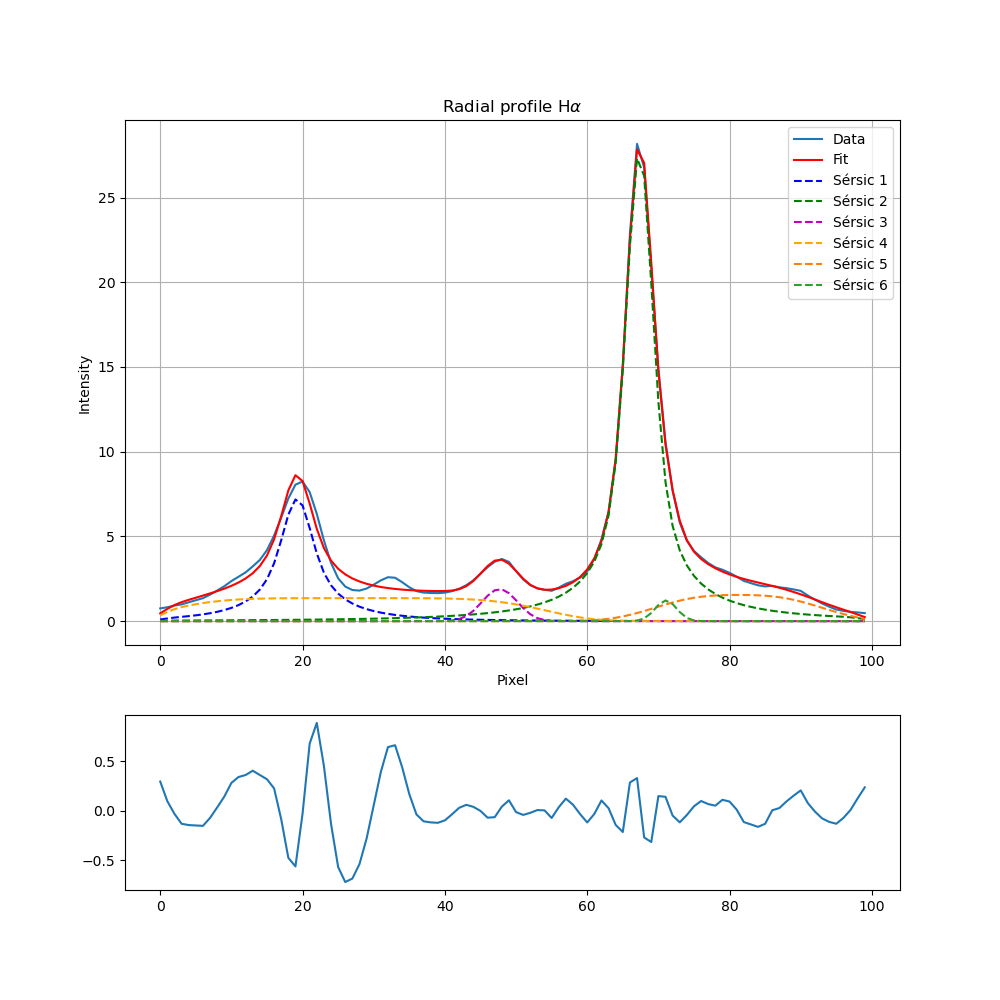

In [27]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [28]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (29, 33),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (80, 90), 
    
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

     (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 2434932.728727169
differential_evolution step 2: f(x)= 2022293.5194989298
differential_evolution step 3: f(x)= 1039842.2764031525
differential_evolution step 4: f(x)= 524052.80095966265
differential_evolution step 5: f(x)= 524052.80095966265
differential_evolution step 6: f(x)= 104380.75651661622
differential_evolution step 7: f(x)= 104380.75651661622
differential_evolution step 8: f(x)= 104380.75651661622
differential_evolution step 9: f(x)= 104380.75651661622
differential_evolution step 10: f(x)= 104380.75651661622
differential_evolution step 11: f(x)= 85624.44670896744
differential_evolution step 12: f(x)= 81908.62553197851
differential_evolution step 13: f(x)= 14048.86698264277
differential_evolution step 14: f(x)= 14048.86698264277
differential_evolution step 15: f(x)= 14048.86698264277
differential_evolution step 16: f(x)= 14048.86698264277
differential_evolution step 17: f(x)= 14048.86698264277
differential_evolution step 18: f(x)= 14048.8669

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\2968413863.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18544\111436280.py:9: RuntimeWarning: overflow encountered in multiply
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=4.3263, r_e=2.7094, n=0.4320, x_0=19.6313
Sérsic 2: I_e=0.0364, r_e=163.5476, n=2.6699, x_0=12.5428
Sérsic 3: I_e=0.6810, r_e=4.8102, n=0.9901, x_0=47.4481
Sérsic 4: I_e=2.0551, r_e=5.6109, n=2.2340, x_0=67.2873
Sérsic 5: I_e=0.3505, r_e=8.4859, n=0.0440, x_0=83.8920
Sérsic 6: I_e=0.1508, r_e=56.7642, n=2.0948, x_0=70.5785
Sérsic 7: I_e=0.1607, r_e=15.4211, n=1.5742, x_0=32.3002
[4.68112461e-01 1.96260603e-01 8.88839322e-02 7.15831856e-02
 6.70063075e-02 3.06643384e+02 1.12972645e+00 3.45456619e-01
 3.00335093e-01 2.19960044e+00 3.30280126e-01 1.20304818e-01
 2.40660594e+00 4.66719907e+00 1.72625952e+00 4.29313165e-02
 1.97755532e+00 1.79229641e+00 1.22288216e-01 4.78950874e-01
 2.40504826e-01 6.33452051e+01 7.89594899e-01 1.10655755e+00
 3.60123362e-01 3.54335290e+01 1.41143181e+00 1.96171782e-01]
10.442493646487142
89.31573308310686 10.442493646487142 139.3872588541537 28


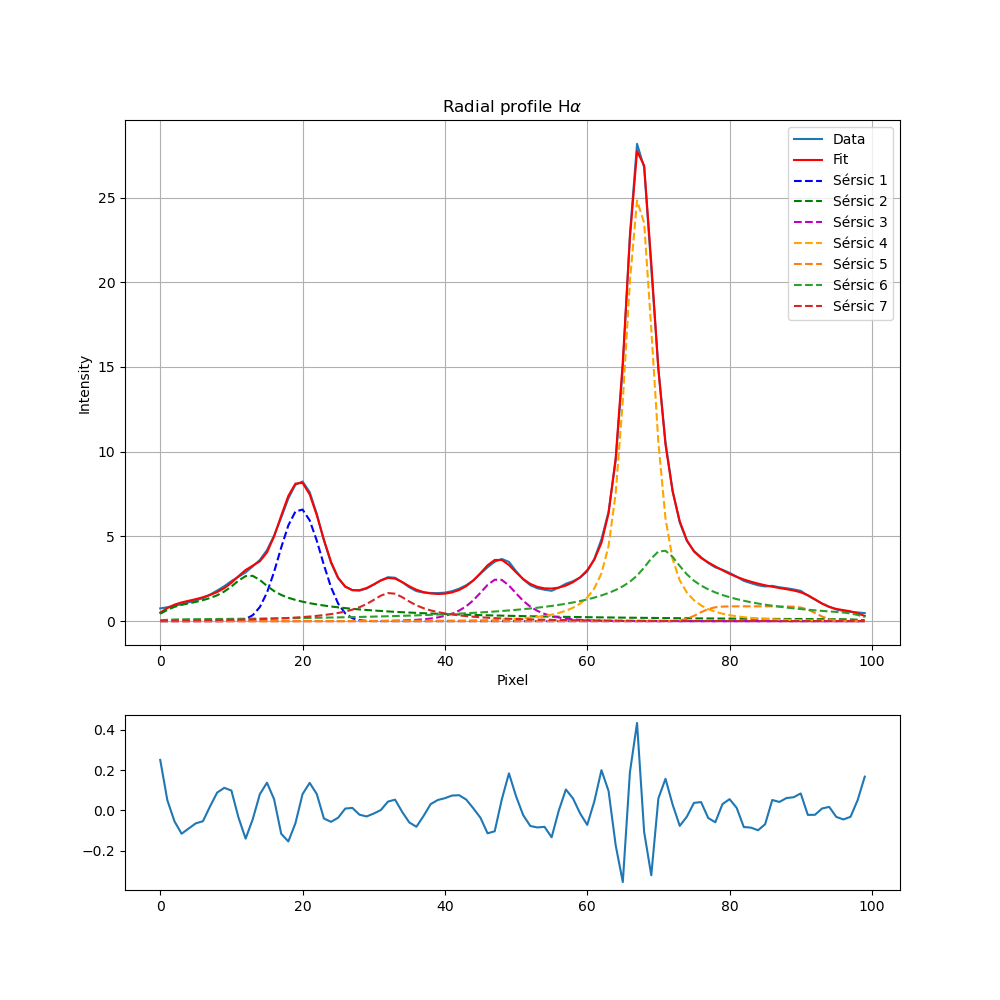

In [30]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, 
                                         sigma = radial_profile_error_HA, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

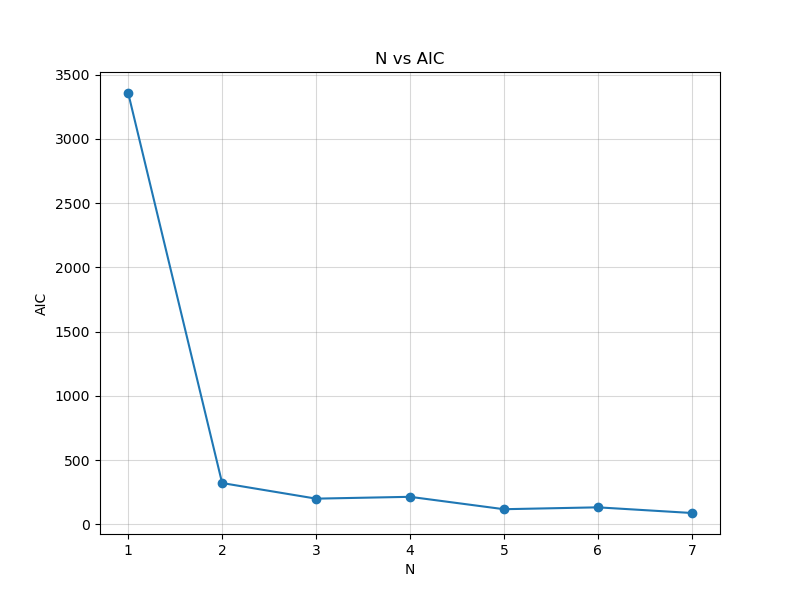

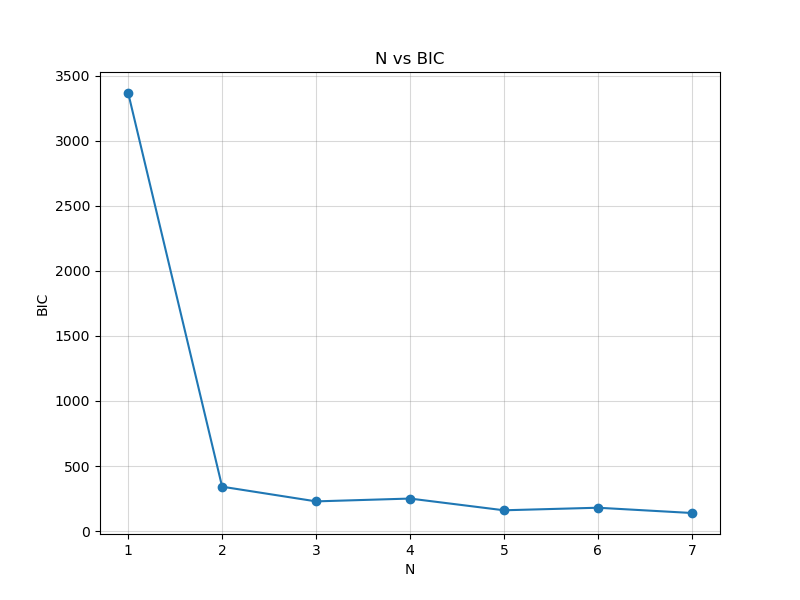

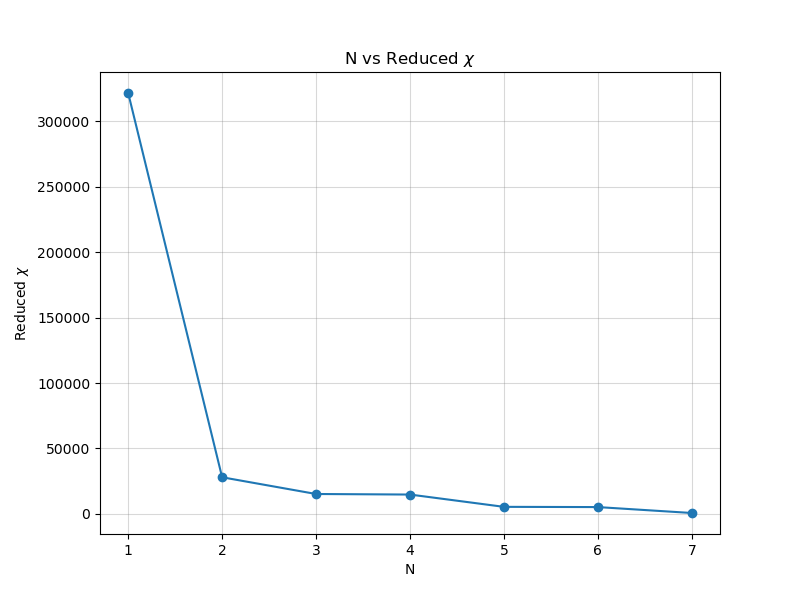

In [31]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N', bbox_inches='tight')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N', bbox_inches='tight')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N', bbox_inches='tight')

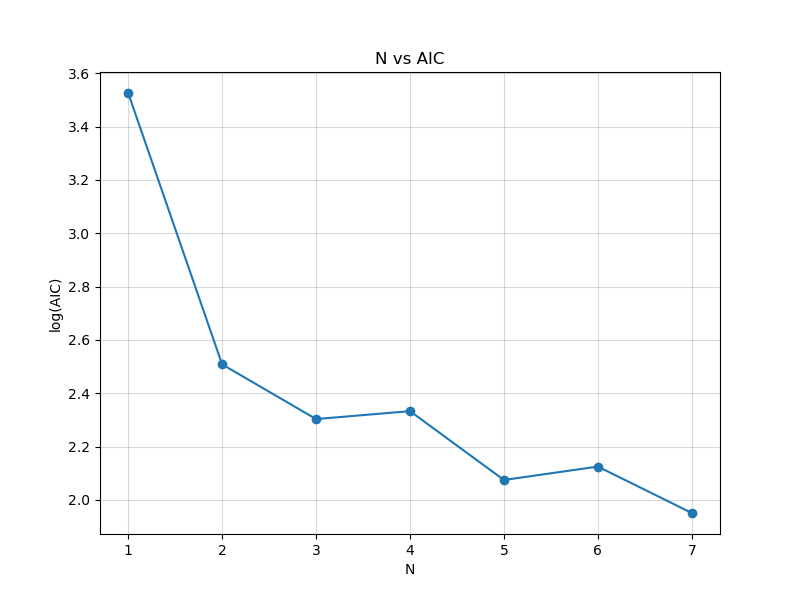

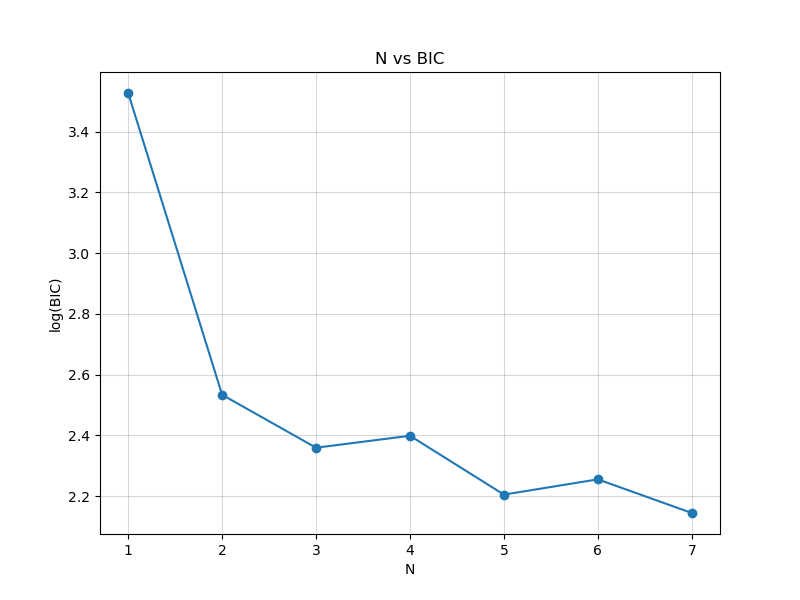

In [32]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log', bbox_inches='tight')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log', bbox_inches='tight')